#### **Import Library** ####

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score  

---

#### **Membaca Data** ####

In [34]:
data_mentah = pd.read_excel("data_mentah.xlsx")

In [35]:
data_mentah

,No.,ID Anggota,Tanggal Pencairan,Nama Anggota,Status Pekerjaan,Besar Pinjaman,Sisa Pinjaman,Angsuran Pokok,Jasa,Tunggakan,Tenor
0,1,722,2019-04-05,Solikin,Dinas,2400000,200000,200000,12000,270000,1
1,2,325,2019-04-09,Murnitasari,Umum,2400000,200000,200000,12000,20400,1
2,3,618,2019-04-04,Seniah,Pensiunan,2040000,170000,170000,10200,153000,1
3,4,696,2019-06-14,Dewi Zuliani,Umum,1500000,375000,125000,22500,148500,3
4,5,799,2020-01-09,Gaguk H P,Umum,3000000,2500000,250000,150000,67500,10
...,...,...,...,...,...,...,...,...,...,...,...
7150,7151,1160,2025-08-12,Wahyu Prasetyo,Umum,3000000,3000000,500000,180000,0,6
7151,7152,931,2025-08-12,Sudarnik,Pensiunan,5040000,5040000,420000,302400,0,12
7152,7153,1179,2025-08-15,Lamsihani,Pensiunan,1020000,1020000,85000,61200,0,12
7153,7154,1090,2025-08-18,Ach. Sujarwadi,Umum,6000000,6000000,1000000,360000,0,6


#### **Info Data** ####

In [36]:
data_mentah.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7155 entries, 0 to 7154
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   No.                7155 non-null   int64         
 1   ID Anggota         7155 non-null   int64         
 2   Tanggal Pencairan  7155 non-null   datetime64[ns]
 3   Nama Anggota       7155 non-null   object        
 4   Status Pekerjaan   7155 non-null   object        
 5   Besar Pinjaman     7155 non-null   int64         
 6   Sisa Pinjaman      7155 non-null   int64         
 7   Angsuran Pokok     7155 non-null   int64         
 8   Jasa               7155 non-null   int64         
 9   Tunggakan          7155 non-null   int64         
 10  Tenor              7155 non-null   int64         
dtypes: datetime64[ns](1), int64(8), object(2)
memory usage: 615.0+ KB


#### **Missing Value** ####

In [37]:
data_mentah.isna().sum()

No.                  0
ID Anggota           0
Tanggal Pencairan    0
Nama Anggota         0
Status Pekerjaan     0
Besar Pinjaman       0
Sisa Pinjaman        0
Angsuran Pokok       0
Jasa                 0
Tunggakan            0
Tenor                0
dtype: int64

---

#### **Preprocessing Data** ####

***Mengubah atribut Tanggal Pencairan menjadi format tanggal tanpa jam***

In [38]:
data_mentah['Tanggal Pencairan'] = pd.to_datetime(data_mentah['Tanggal Pencairan']).dt.date

***Membentuk tunggakan maksimum dari setiap ID Anggota***

In [39]:
data_mentah['Tunggakan Maksimum'] = data_mentah.groupby('ID Anggota')['Tunggakan'].transform('max')

In [40]:
data_mentah

,No.,ID Anggota,Tanggal Pencairan,Nama Anggota,Status Pekerjaan,Besar Pinjaman,Sisa Pinjaman,Angsuran Pokok,Jasa,Tunggakan,Tenor,Tunggakan Maksimum
0,1,722,2019-04-05,Solikin,Dinas,2400000,200000,200000,12000,270000,1,270000
1,2,325,2019-04-09,Murnitasari,Umum,2400000,200000,200000,12000,20400,1,3660700
2,3,618,2019-04-04,Seniah,Pensiunan,2040000,170000,170000,10200,153000,1,153000
3,4,696,2019-06-14,Dewi Zuliani,Umum,1500000,375000,125000,22500,148500,3,148500
4,5,799,2020-01-09,Gaguk H P,Umum,3000000,2500000,250000,150000,67500,10,252000
...,...,...,...,...,...,...,...,...,...,...,...,...
7150,7151,1160,2025-08-12,Wahyu Prasetyo,Umum,3000000,3000000,500000,180000,0,6,0
7151,7152,931,2025-08-12,Sudarnik,Pensiunan,5040000,5040000,420000,302400,0,12,0
7152,7153,1179,2025-08-15,Lamsihani,Pensiunan,1020000,1020000,85000,61200,0,12,0
7153,7154,1090,2025-08-18,Ach. Sujarwadi,Umum,6000000,6000000,1000000,360000,0,6,0


***Mengambil 1 data setiap ID Anggota berdasarkan tenor terkecil***

In [41]:
df = data_mentah.loc[data_mentah.groupby('ID Anggota')['Tenor'].idxmin()].copy()

***Mengatur ulang indeks dan mengurutkan data***

In [42]:
df = df.reset_index(drop=True)
df['No.'] = df.index + 1

In [43]:
df

,No.,ID Anggota,Tanggal Pencairan,Nama Anggota,Status Pekerjaan,Besar Pinjaman,Sisa Pinjaman,Angsuran Pokok,Jasa,Tunggakan,Tenor,Tunggakan Maksimum
0,1,10,2020-04-14,Soepandi/Hentri,Pensiunan,5400000,1800000,450000,108000,252000,4,252000
1,2,26,2020-04-03,Pitran Triyono,Umum,5040000,840000,420000,50400,67500,2,67500
2,3,46,2020-04-03,Soni,Umum,9000000,750000,750000,45000,270000,1,270000
3,4,59,2020-03-17,Juari,Umum,4020000,335000,335000,20100,148500,1,148500
4,5,60,2021-03-03,Didik Subandi,Pensiunan,3000000,750000,250000,45000,695000,1,695000
...,...,...,...,...,...,...,...,...,...,...,...,...
466,467,1178,2025-08-01,Supriadi,Umum,4020000,4020000,335000,241200,0,12,0
467,468,1179,2025-08-15,Lamsihani,Pensiunan,1020000,1020000,85000,61200,0,12,0
468,469,1185,2024-02-19,Jefri Dwi F,Dinas,3000000,2000000,250000,120000,0,8,0
469,470,1198,2022-01-21,Uun Paristyawati,Dinas,4500000,375000,375000,22500,0,1,0


***Memilih atribut-atribut penting yang akan digunakan***

In [44]:
fitur = [
    'Besar Pinjaman',
    'Sisa Pinjaman',
    'Angsuran Pokok',
    'Tenor',
    'Tunggakan Maksimum'
]

***Menampilkan korelasi antar atribut***

In [45]:
corr = df[fitur].corr()
print(corr)

                    Besar Pinjaman  Sisa Pinjaman  Angsuran Pokok  Tenor  \
Besar Pinjaman                   1              1               1      0   
Sisa Pinjaman                    1              1               1      1   
Angsuran Pokok                   1              1               1      0   
Tenor                            0              1               0      1   
Tunggakan Maksimum               0              0               0     -0   

                    Tunggakan Maksimum  
Besar Pinjaman                       0  
Sisa Pinjaman                        0  
Angsuran Pokok                       0  
Tenor                               -0  
Tunggakan Maksimum                   1  


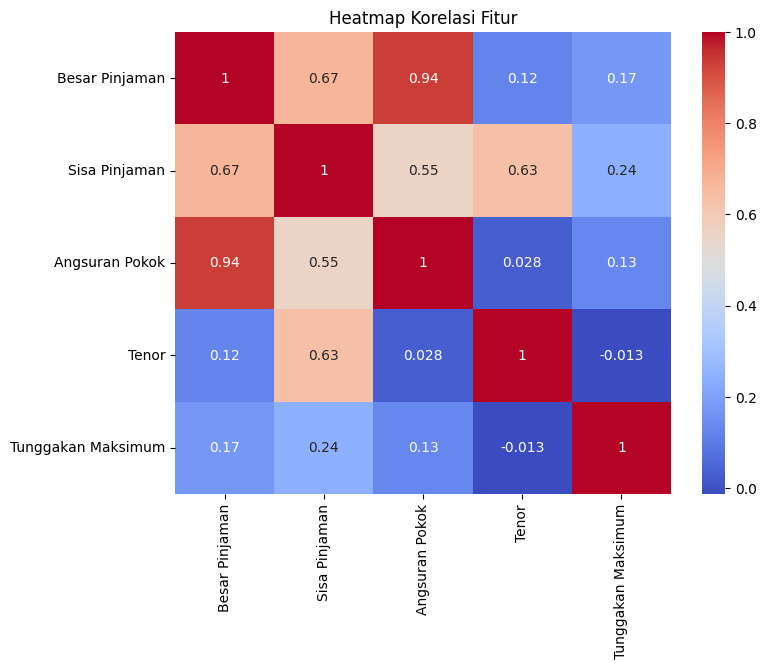

In [46]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi Fitur")
plt.show()

***Menyamakan skala semua fitur (Feature Scaling)***

In [47]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[fitur])
X_scaled = pd.DataFrame(X_scaled, columns=fitur)

In [48]:
X_scaled

,Besar Pinjaman,Sisa Pinjaman,Angsuran Pokok,Tenor,Tunggakan Maksimum
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0
...,...,...,...,...,...
466,0,0,0,1,0
467,0,0,0,1,0
468,0,0,0,0,0
469,0,0,0,0,0


---

#### **K-Means Clustering** ####

***Membuat Model K-Means***

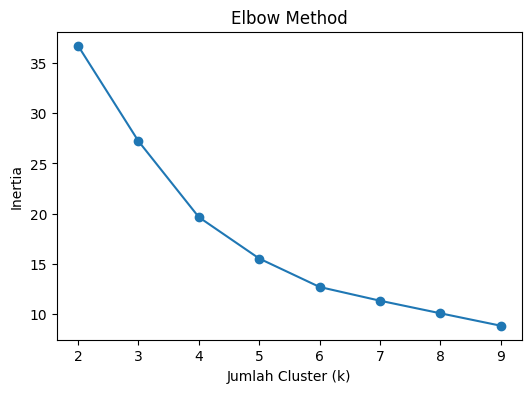

In [49]:
inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


In [50]:
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels_k)
    dbi = davies_bouldin_score(X_scaled, labels_k)
    
    print(f"k={k} | Silhouette={sil:.3f} | DBI={dbi:.3f}")

k=2 | Silhouette=0.563 | DBI=0.966
k=3 | Silhouette=0.557 | DBI=0.901
k=4 | Silhouette=0.466 | DBI=0.847
k=5 | Silhouette=0.430 | DBI=0.881


In [51]:
# Berdasarkan hasil evaluasi, dipilih k = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = labels

# Centroid (opsional untuk analisis)
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=fitur)

print("Centroid Cluster:")
print(centroids)

Centroid Cluster:
   Besar Pinjaman  Sisa Pinjaman  Angsuran Pokok  Tenor  Tunggakan Maksimum
0               0              0               0      0                   0
1               0              0               0      0                   1
2               1              0               1      0                   0


In [52]:
df

,No.,ID Anggota,Tanggal Pencairan,Nama Anggota,Status Pekerjaan,Besar Pinjaman,Sisa Pinjaman,Angsuran Pokok,Jasa,Tunggakan,Tenor,Tunggakan Maksimum,Cluster
0,1,10,2020-04-14,Soepandi/Hentri,Pensiunan,5400000,1800000,450000,108000,252000,4,252000,0
1,2,26,2020-04-03,Pitran Triyono,Umum,5040000,840000,420000,50400,67500,2,67500,0
2,3,46,2020-04-03,Soni,Umum,9000000,750000,750000,45000,270000,1,270000,2
3,4,59,2020-03-17,Juari,Umum,4020000,335000,335000,20100,148500,1,148500,0
4,5,60,2021-03-03,Didik Subandi,Pensiunan,3000000,750000,250000,45000,695000,1,695000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,467,1178,2025-08-01,Supriadi,Umum,4020000,4020000,335000,241200,0,12,0,0
467,468,1179,2025-08-15,Lamsihani,Pensiunan,1020000,1020000,85000,61200,0,12,0,0
468,469,1185,2024-02-19,Jefri Dwi F,Dinas,3000000,2000000,250000,120000,0,8,0,0
469,470,1198,2022-01-21,Uun Paristyawati,Dinas,4500000,375000,375000,22500,0,1,0,0


---

#### **Labeling & Evaluasi Hasil** ####

***Mengubah cluster menjadi label kategori risiko***

In [53]:
cluster_mean = df.groupby('Cluster')['Tunggakan Maksimum'].mean().sort_values()

labels_risiko = ['Rendah', 'Sedang', 'Tinggi']
mapping = {cluster: labels_risiko[i] for i, cluster in enumerate(cluster_mean.index)}

df['Risiko'] = df['Cluster'].map(mapping)

In [54]:
df

,No.,ID Anggota,Tanggal Pencairan,Nama Anggota,Status Pekerjaan,Besar Pinjaman,Sisa Pinjaman,Angsuran Pokok,Jasa,Tunggakan,Tenor,Tunggakan Maksimum,Cluster,Risiko
0,1,10,2020-04-14,Soepandi/Hentri,Pensiunan,5400000,1800000,450000,108000,252000,4,252000,0,Rendah
1,2,26,2020-04-03,Pitran Triyono,Umum,5040000,840000,420000,50400,67500,2,67500,0,Rendah
2,3,46,2020-04-03,Soni,Umum,9000000,750000,750000,45000,270000,1,270000,2,Sedang
3,4,59,2020-03-17,Juari,Umum,4020000,335000,335000,20100,148500,1,148500,0,Rendah
4,5,60,2021-03-03,Didik Subandi,Pensiunan,3000000,750000,250000,45000,695000,1,695000,0,Rendah
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,467,1178,2025-08-01,Supriadi,Umum,4020000,4020000,335000,241200,0,12,0,0,Rendah
467,468,1179,2025-08-15,Lamsihani,Pensiunan,1020000,1020000,85000,61200,0,12,0,0,Rendah
468,469,1185,2024-02-19,Jefri Dwi F,Dinas,3000000,2000000,250000,120000,0,8,0,0,Rendah
469,470,1198,2022-01-21,Uun Paristyawati,Dinas,4500000,375000,375000,22500,0,1,0,0,Rendah


***Menghitung jumlah data pada setiap kelas***

In [55]:
print(df['Risiko'].value_counts())

Risiko
Rendah    398
Tinggi     47
Sedang     26
Name: count, dtype: int64


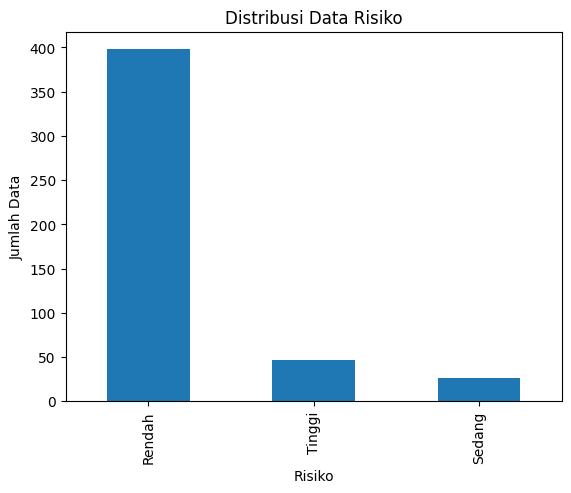

In [56]:
df['Risiko'].value_counts().plot(kind='bar')
plt.title("Distribusi Data Risiko")
plt.xlabel("Risiko")
plt.ylabel("Jumlah Data")
plt.show()

***Sebaran data berdasarkan risiko***

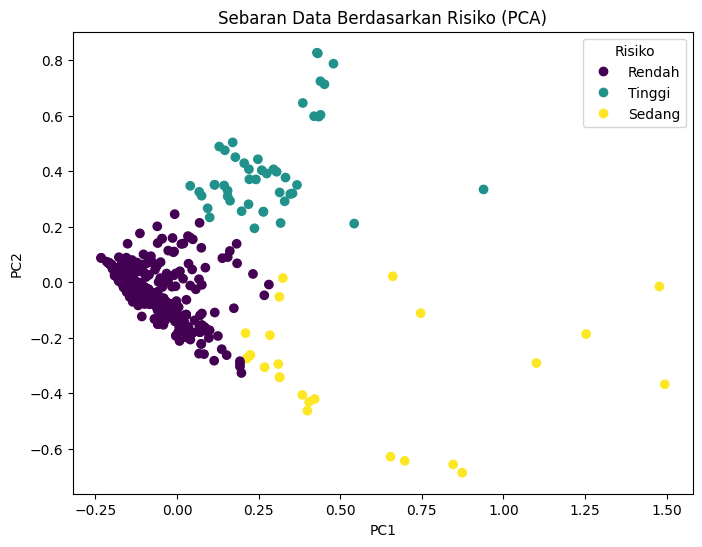

In [57]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'])
handles, _ = scatter.legend_elements()

unique_labels = df[['Cluster', 'Risiko']].drop_duplicates().sort_values('Cluster')

plt.legend(
    handles=handles,
    labels=unique_labels['Risiko'].tolist(),
    title="Risiko"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Sebaran Data Berdasarkan Risiko (PCA)")
plt.show()

***Evaluasi kualitas hasil clustering***

In [58]:
sil_score = silhouette_score(X_scaled, labels)
dbi_score = davies_bouldin_score(X_scaled, labels)

print("Silhouette Score :", sil_score)
print("Davies-Bouldin Index :", dbi_score)

Silhouette Score : 0.5567119528467812
Davies-Bouldin Index : 0.9010101144043872


In [59]:
df.groupby('Cluster')[fitur].mean()

print("\nRata-rata tiap cluster:")
print(df.groupby('Cluster')[fitur].mean())
pd.options.display.float_format = '{:,.0f}'.format


Rata-rata tiap cluster:
         Besar Pinjaman  Sisa Pinjaman  Angsuran Pokok  Tenor  \
Cluster                                                         
0             3,161,407        753,819         271,595      3   
1             3,099,574        684,681         258,298      2   
2            14,315,192      4,161,154       1,059,231      3   

         Tunggakan Maksimum  
Cluster                      
0                   106,352  
1                 2,582,368  
2                   869,381  


In [60]:
print("Urutan cluster berdasarkan tunggakan:")
print(cluster_mean)
pd.options.display.float_format = '{:,.0f}'.format

print("\nMapping cluster ke risiko:")
print(mapping)

Urutan cluster berdasarkan tunggakan:
Cluster
0     106,352
2     869,381
1   2,582,368
Name: Tunggakan Maksimum, dtype: float64

Mapping cluster ke risiko:
{0: 'Rendah', 2: 'Sedang', 1: 'Tinggi'}


In [61]:
#### =========================================================
#### UJI STABILITAS CLUSTER
#### =========================================================

cluster_results = []

random_states = [1, 10, 20, 30, 42]

for rs in random_states:

    model = KMeans(
        n_clusters=3,
        random_state=rs,
        n_init=10
    )

    labels_test = model.fit_predict(X_scaled)

    cluster_results.append(labels_test)

print("\n=== Uji Stabilitas Cluster ===")

ari_scores = []

for i in range(len(cluster_results)-1):

    ari = adjusted_rand_score(
        cluster_results[i],
        cluster_results[i+1]
    )

    ari_scores.append(ari)

    print(
        f"ARI Random State "
        f"{random_states[i]} vs "
        f"{random_states[i+1]} : "
        f"{round(ari, 4)}"
    )

print(
    "\nRata-rata ARI :",
    round(sum(ari_scores)/len(ari_scores), 4)
)



=== Uji Stabilitas Cluster ===
ARI Random State 1 vs 10 : 1.0
ARI Random State 10 vs 20 : 0.9984
ARI Random State 20 vs 30 : 1.0
ARI Random State 30 vs 42 : 0.9219

Rata-rata ARI : 0.9801


In [62]:
#### =========================================================
#### MENAMPILKAN DATA AKHIR
#### =========================================================

print("\nData Akhir:")

print(df.head())


Data Akhir:
   No.  ID Anggota Tanggal Pencairan     Nama Anggota Status Pekerjaan  \
0    1          10        2020-04-14  Soepandi/Hentri        Pensiunan   
1    2          26        2020-04-03   Pitran Triyono             Umum   
2    3          46        2020-04-03             Soni             Umum   
3    4          59        2020-03-17            Juari             Umum   
4    5          60        2021-03-03    Didik Subandi        Pensiunan   

   Besar Pinjaman  Sisa Pinjaman  Angsuran Pokok    Jasa  Tunggakan  Tenor  \
0         5400000        1800000          450000  108000     252000      4   
1         5040000         840000          420000   50400      67500      2   
2         9000000         750000          750000   45000     270000      1   
3         4020000         335000          335000   20100     148500      1   
4         3000000         750000          250000   45000     695000      1   

   Tunggakan Maksimum  Cluster  Risiko  
0              252000        0  

In [63]:
df.to_excel("data_hasil_kmeans.xlsx", index=False)

In [65]:
import joblib

joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']